# Ridge Regularization - (l2 regularization)

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
X = data.data
y = data.target

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import  LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# predict 
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import r2_score,mean_squared_error
score_1 = r2_score(y_test,y_pred)
score_2 = np.sqrt(mean_squared_error(y_test,y_pred))
print("r2_score :",score_1)
print("RMSE :",score_2)

r2_score : 0.4526027629719195
RMSE : 53.85344583676593


In [33]:
from sklearn.linear_model import Ridge
model_rd = Ridge(alpha=0.001)
model_rd.fit(X_train,y_train)

,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [34]:
y_pred = model_rd.predict(X_test)
from sklearn.metrics import r2_score,mean_squared_error
score_1 = r2_score(y_test,y_pred)
score_2 = np.sqrt(mean_squared_error(y_test,y_pred))
print("r2_score :",score_1)
print("RMSE :",score_2)

r2_score : 0.4534280301019329
RMSE : 53.81283525336318


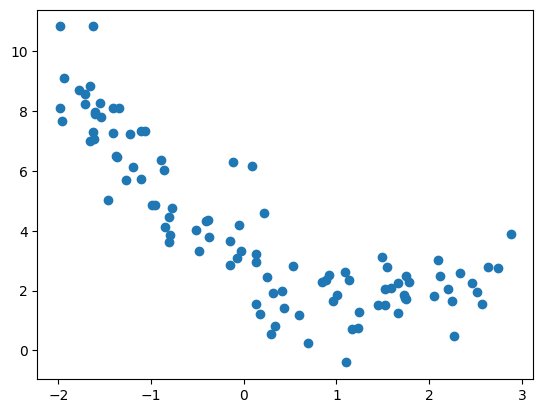

In [35]:
# create a random dataset 
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

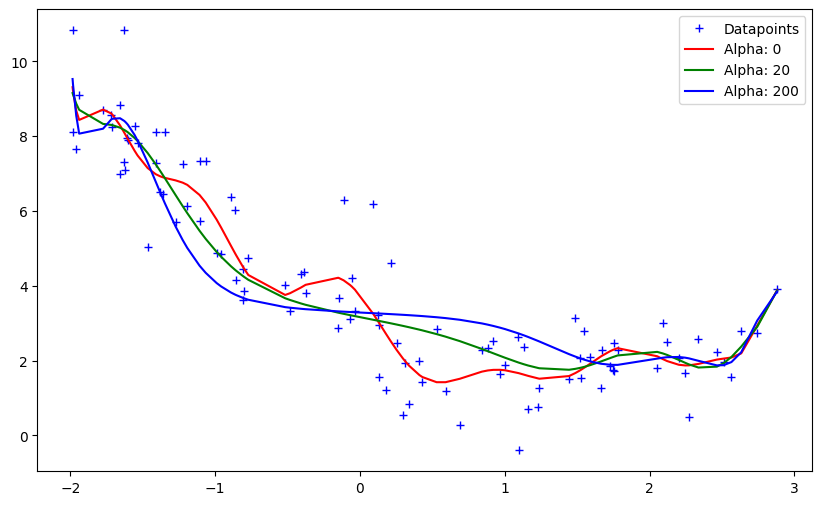

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def ridge_implentation(x1,x2,alpha):

    model = Pipeline([
        ('poly_feature:',PolynomialFeatures(degree=16)),
        ('ridge :',Ridge(alpha=alpha))
    ])

    model.fit(x1,x2)
    return model.predict(x1)

alphas =[0,20,200]
color =['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label= 'Datapoints')


for alpha, c in zip(alphas, color):
    preds = ridge_implentation(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

# Ridge Regression from scratch

### comaprison with Linear model 

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

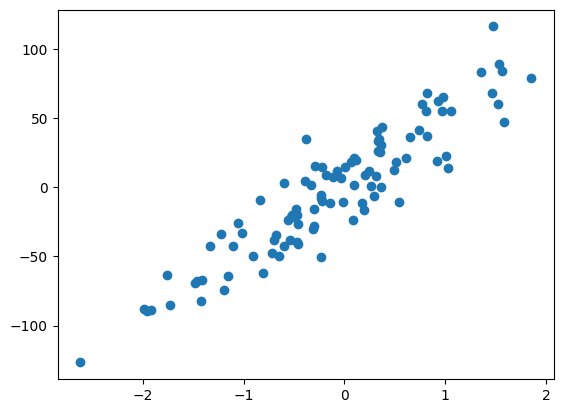

In [3]:
X,y  = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=42)
plt.scatter(X,y)

In [4]:
# create a  linear model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
print(model.coef_)
print(model.intercept_)

[47.13323967]
2.3302306410539453


In [6]:
# create a Ridge model
from sklearn.linear_model import Ridge
model_R = Ridge(alpha=10)
model_R.fit(X,y)
print(model_R.coef_)
print(model_R.intercept_)

[41.9906212]
1.7961876226164746


In [7]:
model_R100 = Ridge(alpha=100)
model_R100.fit(X,y)
print(model_R100.coef_)
print(model_R100.intercept_)

[21.18627364]
-0.3642714175995887


In [9]:
model_R0 = Ridge(alpha=0)
model_R0.fit(X,y)
print(model_R0.coef_)
print(model_R0.intercept_)

[47.13323967]
2.330230641053946


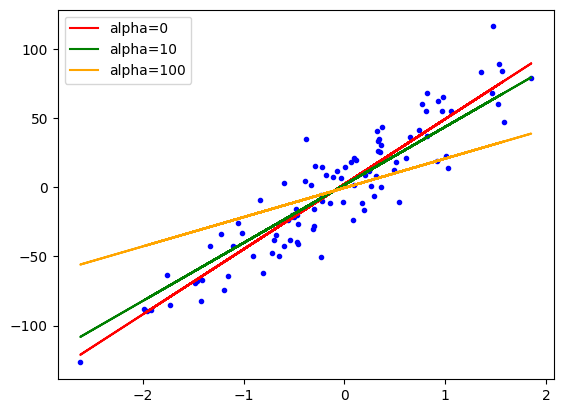

In [10]:
plt.plot(X,y,'b.')
plt.plot(X,model_R0.predict(X),color='red',label='alpha=0')
plt.plot(X,model_R.predict(X),color='green',label='alpha=10')
plt.plot(X,model_R100.predict(X),color='orange',label='alpha=100')
plt.legend()

In [1]:
### create a class from sctrach
# for linear model
def linear_model(x,y,alpha =1):
    x_mean = x.mean()
    y_mean = y.mean()

    numerator =0
    denominator = 0

    for i in range(X.shape[0]):
        numerator = numerator + (y[i]-y_mean) * (x[i] - x_mean)
        denominator = denominator +(x[i] - x_mean) * (x[i] - x_mean)

    m =numerator/(denominator + alpha)
    b = y_mean  - m*x_mean

    return m,b

In [2]:
# for ridge regression 
class myridge :
    def __init__(self,alpha =0.1):
        self.aplha = alpha
        self.m = None
        self.b = None 

    def fit(self,X_train,y_train):
        numerator  = 0
        denominator  = 0

        for i in range(X_train.shape[0]):
            numerator = numerator + (y_train[i]-y_train.mean()) * (X_train[i] - X_train.mean())
            denominator = denominator +(X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())

        self.m = numerator /(denominator+self.alpha)
        self.b = y_train.mean() -(self.m * X_train.mean())
        print(self.m,self.b)
            
    def predict(X_test):
        pass
        

### sklearn Implementation

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [4]:
X,y = load_diabetes(return_X_y = True)

In [5]:
from sklearn.model_selection import  train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
# train model 
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.1, solver='cholesky')
model.fit(X_train,y_train)

# prediction 
y_pred = model.predict(X_test)
r2_score(y_test,y_pred)

0.46085219464119265

In [7]:
print(model.coef_)
print(model.intercept_)

[  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]
151.45857456679613


In [18]:
# create a class from  sctrach (on basis of derivation)
class derRidge:

    def __init__(self,alpha =0.1):
        self.aplha = alpha
        self.coef_ = None
        self.intercept_ = None 
        

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])

        result =  np.linalg.inv(np.dot(X_train.T ,X_train) + self.aplha *I).dot(X_train.T).dot(y_train)
        self.intercept_ =  result [0]
        self.coef_ = result[1 :]

        
    def predict(self,X_test):
        return  np.dot(X_test,self.coef_)+self.intercept_


In [20]:
model = derRidge()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [22]:
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

0.460791139668318
[  42.87709893 -205.49834268  505.10960427  317.09526097 -108.51126124
  -86.2562279  -190.37246178  151.70037599  392.29679967   79.93194581]
151.4155298431294


## Why My Scratch Ridge Regression Gives Slightly Different Results

The scratch implementation gives slightly different results from `sklearn.Ridge` mainly because the **intercept is also being regularized** in the current implementation. After adding a column of `1`s to represent the intercept, you create an identity matrix using `np.identity(X_train.shape[1])`. This puts `1` at `I[0,0]`, which means the Ridge penalty is applied to the intercept along with all feature coefficients:

\[
\alpha(\beta_0^2 + \beta_1^2 + \beta_2^2 + \cdots + \beta_p^2)
\]

However, `sklearn.Ridge` **does not regularize the intercept**; it only applies the penalty to the feature coefficients:

\[
\alpha(\beta_1^2 + \beta_2^2 + \cdots + \beta_p^2)
\]

Therefore, after creating the identity matrix, we should set:

```python
I[0, 0] = 0
    

# Ridge Regression(Gradeint descent)

In [24]:
# implement sklearn(ridge gradient reg SGD regressor )
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

# load the data
X, y = load_diabetes(return_X_y = True)

# split the dataset 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

# import SGD regressor 
from sklearn.linear_model import SGDRegressor
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

# fit the model 
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.45226164918325973
[  49.44447274 -134.61559661  400.06675329  268.52505932  -29.54148382
  -69.17845931 -185.23374148  139.14764695  303.27547637  118.74840756]
[149.97741677]


In [25]:
# implement using sklearn(solver method)

from sklearn.linear_model import Ridge
reg = Ridge(alpha =0.001,max_iter=500,solver='sparse_cg')

reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.45342802980618724
[  38.48350697 -241.35179372  543.83518162  346.78283303 -827.70199148
  437.17375182  116.9497504   260.75926817  696.12922689   49.74344986]
151.34198054847556


In [26]:
# create a class  from sctrach

class mygradient_ridge():

    def __init__(self,epochs,learning_rate ,alpha):
        self.learning_rate = learning_rate
        self.epochs =epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ =  None

    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [27]:
reg = mygradient_ridge(epochs=500,alpha=0.001,learning_rate=0.005)

In [28]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4592249376936409
[  43.37183861 -192.03766574  496.43542567  319.37407     -64.42788084
 -113.194338   -213.9073644   144.86136322  367.67948022  119.56857869]
151.4045475591972


# How are coefficents affected 

In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
data = load_diabetes()

In [3]:
df = pd.DataFrame(data.data ,columns =data.feature_names)
df['Target'] = data.target

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.shape

(442, 11)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data ,data.target,test_size =0.2,random_state=42)

In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [8]:
coefs = []
r2_scores = []

for i in [0, 10, 100, 1000]:
    model = Ridge(alpha=i)
    model.fit(X_train, y_train)

    coefs.append(model.coef_.tolist())

    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

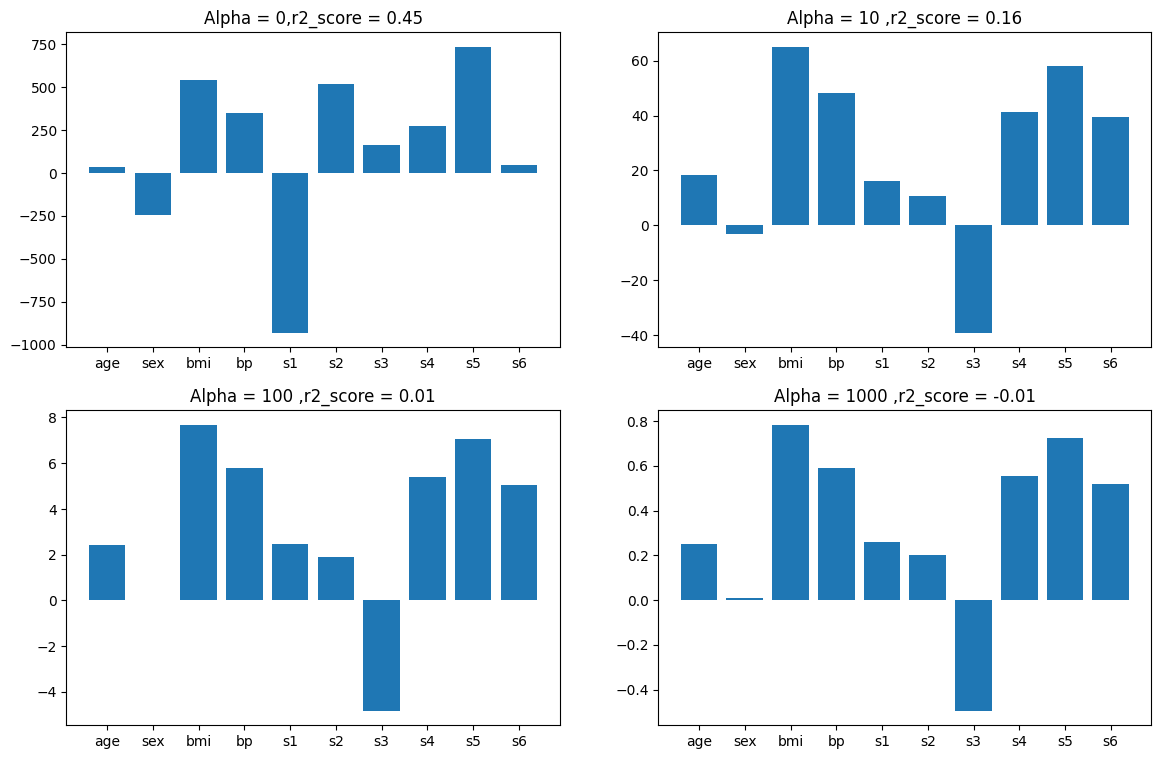

In [9]:
plt.figure(figsize = (14 ,9))

plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title('Alpha = 0,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

# Higher Coefficients are affected more 

In [10]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [11]:
input_array = np.array(coefs).T

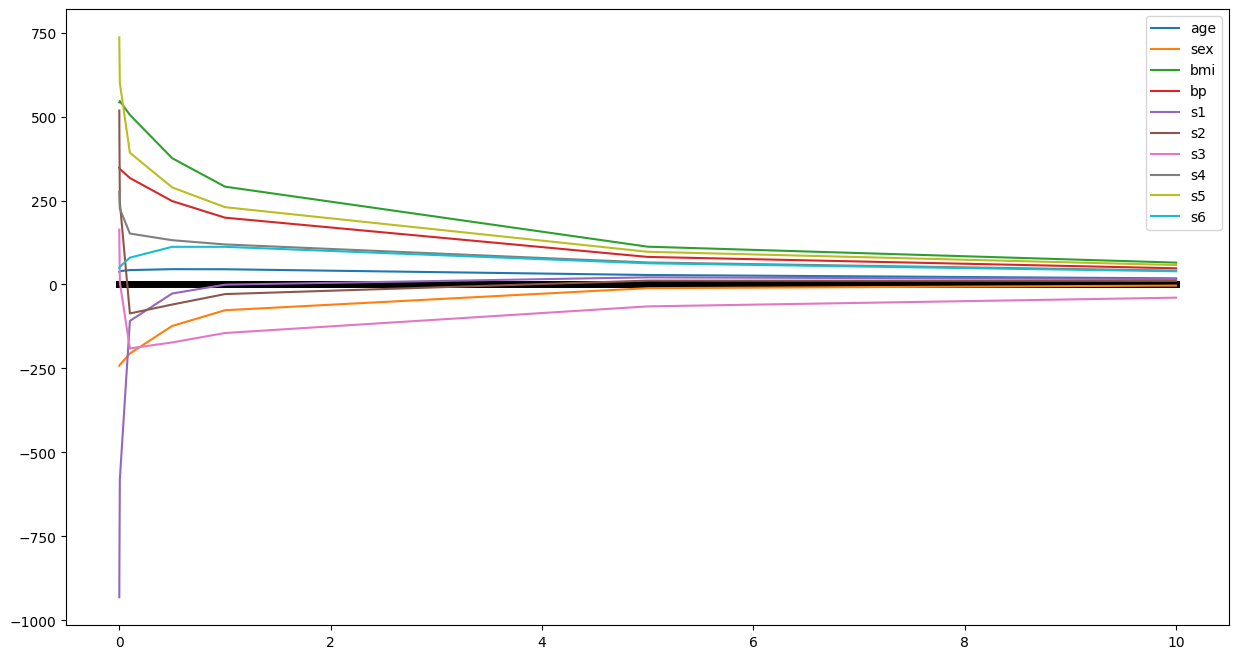

In [12]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

# Impact on  Bias and variance 

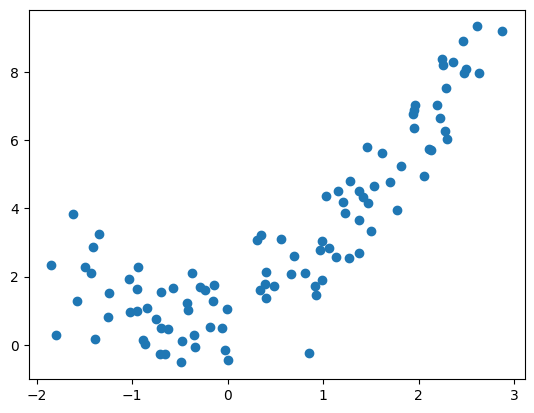

In [24]:
m = 100 
X = 5 * np.random.rand(m ,1)- 2
y = 0.7 * X ** 2 - 2 + X + 3 + np.random.randn(m,1)

plt.scatter(X,y)
plt.show()

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [26]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [27]:
!pip install mlxtend


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [30]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=111)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

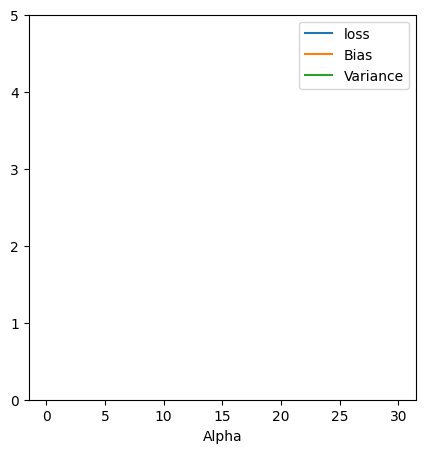

In [31]:
plt.figure(figsize=(5,5))
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.ylim(0,5)
plt.xlabel('Alpha')
plt.legend()

# Effect on Regularization

[27.82809103]
-2.29474455867698


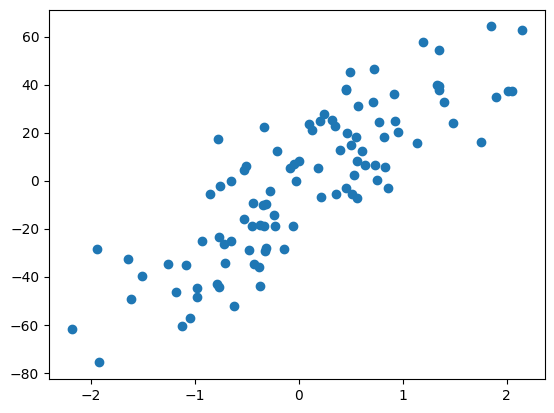

In [32]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [33]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [34]:
def predict(m):
    return m*X - 2.29

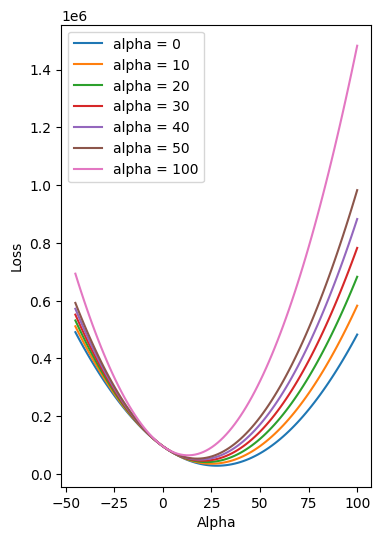

In [35]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()